***Week 2 Jupyter Notebook — Linear Regression 2 Instructions***

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data, using the methods you have learned about in this course and in this program, and draw interesting conclusions. 

For Week 2, include concepts such as linear regression with lasso, ridge, and elastic net regression. This homework will be submitted for peer review and feedback in Week 4 in the assignment titled 4.3 Peer Review: Week 2 Jupyter Notebook. Complete your Jupyter Notebook homework by 11:59 pm ET on Sunday.

# Week 2: Ridge, lasso, and elastic net regression

**Assignment coverage:** OLS benchmark; L2/ridge, L1/lasso, and combined elastic net penalties; fold-specific scaling; hyperparameter tuning; coefficient shrinkage and sparsity; validation/test comparison; conclusions.

**Expanded coverage:** this notebook applies the weekly methods independently to all three CSV files in `DATA`. Each dataset has its own response, preparation, model selection, diagnostics, and conclusions. Metrics with different outcomes or units must not be ranked against one another.

## Results across all three datasets

- **accepted_2007_to_2018Q4.csv**: Lasso; test RMSE **3.064 percentage points**, MAE **2.414 percentage points**, R² **0.492**, test n = **4,800**. Development-mean baseline RMSE: **4.299 percentage points**.
- **Loan_Default.csv**: OLS; test RMSE **0.442 percentage points**, MAE **0.349 percentage points**, R² **0.355**, test n = **4,800**. Development-mean baseline RMSE: **0.551 percentage points**.
- **bank_customers.csv**: OLS; test RMSE **11.176 years**, MAE **9.722 years**, R² **-0.156**, test n = **8**. Development-mean baseline RMSE: **12.141 years**.

Each dataset now has its own full application of this week's required methods. LendingClub models issued rates in a 2015 cohort; Loan_Default models observed rates in a heavily selected subset; bank_customers models historical account tenure. Their errors use different populations and, for the bank file, different units. The small bank holdout is a method demonstration, not a reliable performance claim. The dataset-specific conclusions above explain the observed selection, shrinkage, or component tradeoff. No result establishes causality or future-cohort validity.

The prose describes this saved run. If inputs or parameters change, rerun all code and revise the narrative to match.

## A. accepted_2007_to_2018Q4.csv — independent analysis

## Context & methods

**Question:** How well can application and contract attributes explain the issued
interest rate of a loan, and what does this week's method change?
The response is `int_rate`, measured in percent; prediction errors are reported in
**percentage points (pp)**. A rate of 12 is 12%, not 0.12%.

**Source:** `DATA/accepted_2007_to_2018Q4.csv`. The analysis takes a reproducible,
uniform sample of 24,000 eligible loans issued in **2015**, scanning the whole CSV
in chunks. One origination year limits changes in lending policy across years.
The model explains rates on accepted loans; it does not estimate default risk,
approval probability, or causal effects. Weeks 1–3 deliberately reuse the same
sample and 60%/20%/20% training/validation/test partitions for comparability.

### Key assumptions

- Rows represent distinct loans; unique sampled loan IDs are checked. The file
  does not provide a usable borrower-group design here, so repeat-borrower
  dependence remains possible. A random split evaluates same-cohort performance,
  not future-year generalization.
- `int_rate` must be observed and in (0, 100]. Missing predictors are imputed using
  training data. Large positive incomes and utilization over 100 are retained;
  they are not silently removed. Log transforms reduce income/amount skew.
- Grade, subgrade, installment, funded amounts, payment/recovery fields, and later
  loan status are excluded from predictors: some directly encode pricing, are
  redundant, or occur after origination. Contract term and verification status
  make this an **issued-rate explanation**, not a pre-application quote model.
- Categorical values use one-hot indicators with a dropped reference level.
  Continuous variables are standardized inside each fitted pipeline. Employment
  duration is approximate and top-coded. No external data dictionary/rubric was
  included, so undocumented coding and units are not invented.
- Hyperparameters and model families are chosen without test outcomes. Every
  learned transformation is fitted inside the appropriate training/CV partition.
  The final test is opened once per notebook; the three notebooks are related
  instructional comparisons, not independent confirmatory experiments.

**Run instructions:** Install `requirements-notebooks.txt`, select a Python
kernel, and use **Restart Kernel → Run All**. Each notebook is self-contained and
reads the original CSV; no earlier notebook or temporary cache is required.

### 1. Set up a reproducible Python environment

Imports, a fixed random seed, readable charts, and explicit package versions make the analysis auditable.

In [1]:
from pathlib import Path
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

# A fixed seed and bounded numerical threads make the workflow repeatable.
SEED = 42
thread_limit = threadpool_limits(limits=1)
warnings.filterwarnings('error', category=ConvergenceWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'figure.dpi': 115,
                     'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'axes.axisbelow': True})
BLUE, ORANGE, GRAY = '#245E91', '#B96520', '#50545A'

# Support opening from the repository itself or its parent workspace.
data_candidates = [Path.cwd() / 'DATA',
                   Path.cwd() / 'Data-Science-Capstone-DX799' / 'DATA']
DATA_DIR = next((p for p in data_candidates if p.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Open this notebook from the repository or its parent; DATA is required.')
display(pd.Series({'Python': platform.python_version(), 'pandas': pd.__version__,
                   'NumPy': np.__version__, 'scikit-learn': sklearn.__version__,
                   'SciPy': scipy.__version__, 'seed': SEED}, name='Execution environment'))

Python          3.13.5
pandas           3.0.0
NumPy            2.4.1
scikit-learn     1.8.0
SciPy           1.17.0
seed                42
Name: Execution environment, dtype: object

### 2. Load and reconcile the 2015 lending cohort

The large CSV is streamed in chunks. Random priorities give every eligible row the same inclusion probability.

In [2]:
SOURCE = DATA_DIR / 'accepted_2007_to_2018Q4.csv'
COHORT_YEAR = '2015'
SAMPLE_SIZE = 24_000
USECOLS = ['id', 'loan_amnt', 'funded_amnt', 'int_rate', 'term', 'annual_inc',
           'fico_range_low', 'fico_range_high', 'dti', 'revol_util', 'emp_length',
           'earliest_cr_line', 'open_acc', 'home_ownership', 'verification_status',
           'purpose', 'issue_d']
rng = np.random.default_rng(SEED)
sample = pd.DataFrame()
source_rows = cohort_rows = eligible_rows = 0

# Read the complete file in chunks, then retain the smallest independent random
# priorities. This is a uniform sample without replacement, not the first 24,000
# rows (the source is not randomly ordered). Memory stays bounded.
for chunk in pd.read_csv(SOURCE, usecols=USECOLS, chunksize=150_000, low_memory=False):
    source_rows += len(chunk)
    cohort = chunk.loc[chunk['issue_d'].astype('str').str.endswith(COHORT_YEAR)].copy()
    cohort_rows += len(cohort)
    rate = pd.to_numeric(cohort['int_rate'], errors='coerce')
    cohort = cohort.loc[rate.gt(0) & rate.le(100)].copy()
    eligible_rows += len(cohort)
    if not cohort.empty:
        cohort['_priority'] = rng.random(len(cohort))
        sample = pd.concat([sample, cohort.nsmallest(SAMPLE_SIZE, '_priority')])
        sample = sample.nsmallest(SAMPLE_SIZE, '_priority')
sample = sample.drop(columns='_priority').reset_index(drop=True)
assert len(sample) == SAMPLE_SIZE and sample['id'].notna().all()
assert sample['id'].is_unique, 'Repeated loan IDs require a grouped split.'
assert sample['int_rate'].between(0, 100, inclusive='right').all()
display(pd.Series({'source CSV rows': source_rows, '2015 rows': cohort_rows,
                   'eligible positive-rate rows': eligible_rows,
                   'excluded missing/invalid rates': cohort_rows - eligible_rows,
                   'sampled loans': len(sample), 'source bytes': SOURCE.stat().st_size},
                  name='Source and cohort reconciliation'))
# Exclude identifiers and free-text personal information from displayed records.
display(sample[['loan_amnt', 'int_rate', 'term', 'annual_inc',
                'fico_range_low', 'dti', 'home_ownership']].head())

source CSV rows                      2260701
2015 rows                             421095
eligible positive-rate rows           421095
excluded missing/invalid rates             0
sampled loans                          24000
source bytes                      1675133810
Name: Source and cohort reconciliation, dtype: int64

,loan_amnt,int_rate,term,annual_inc,fico_range_low,dti,home_ownership
0,"20,225.0000",18.8400,60 months,"90,000.0000",685.0000,12.5200,RENT
1,"35,000.0000",7.8900,36 months,"140,000.0000",775.0000,8.7200,MORTGAGE
2,"10,000.0000",12.3900,36 months,"74,000.0000",695.0000,13.3500,RENT
3,"21,275.0000",18.4900,60 months,"210,000.0000",695.0000,3.3500,RENT
4,"31,175.0000",11.4900,36 months,"185,000.0000",695.0000,13.8600,RENT


### 3. Engineer interpretable features and reserve evaluation data

Only row-wise feature construction happens before splitting. The final test outcomes are not inspected during model selection.

In [3]:
# These are row-wise transformations with fixed rules, so they do not learn from
# validation/test data. Imputation, scaling, and encoding are fitted later.
X = pd.DataFrame(index=sample.index)
X['log_loan_amount'] = np.log1p(sample['loan_amnt'].where(sample['loan_amnt'] > 0))
X['log_annual_income'] = np.log1p(sample['annual_inc'].where(sample['annual_inc'] >= 0))
X['fico_mid'] = (sample['fico_range_low'] + sample['fico_range_high']) / 2
X['dti'] = sample['dti'].where(sample['dti'] >= 0)
X['revol_util'] = sample['revol_util'].where(sample['revol_util'] >= 0)
# '< 1 year' is represented by 0.5; '10+ years' by 10 (a top-coded value).
employment_map = {'< 1 year': 0.5, '1 year': 1, '10+ years': 10}
employment_map.update({f'{i} years': i for i in range(2, 10)})
X['employment_years'] = sample['emp_length'].map(employment_map)
issued = pd.to_datetime(sample['issue_d'], format='%b-%Y', errors='coerce')
first_credit = pd.to_datetime(sample['earliest_cr_line'], format='%b-%Y', errors='coerce')
X['credit_history_years'] = ((issued - first_credit).dt.days / 365.25).clip(lower=0)
X['open_acc'] = sample['open_acc'].where(sample['open_acc'] >= 0)
NUMERIC = list(X.columns)
CATEGORICAL = ['term', 'home_ownership', 'verification_status', 'purpose']
for name in CATEGORICAL:
    X[name] = sample[name].str.strip().astype(object).where(sample[name].notna(), np.nan)
y = sample['int_rate'].astype(float)

# Reserve the test partition before any data-driven model selection.
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=SEED)
assert not (set(X_train.index) & set(X_valid.index) or
            set(X_dev.index) & set(X_test.index))
assert len(X_train) + len(X_valid) + len(X_test) == len(sample)
display(pd.Series({'training': len(X_train), 'validation': len(X_valid),
                   'test (sealed until final evaluation)': len(X_test)}, name='Partition sizes'))
display(X_train.isna().mean().mul(100).sort_values(ascending=False)
        .rename('Training missing (%)').to_frame())

training                                14400
validation                               4800
test (sealed until final evaluation)     4800
Name: Partition sizes, dtype: int64

,Training missing (%)
employment_years,5.7708
revol_util,0.0347
log_loan_amount,0.0000
log_annual_income,0.0000
fico_mid,0.0000
dti,0.0000
credit_history_years,0.0000
open_acc,0.0000
term,0.0000
home_ownership,0.0000


### 4. Define preprocessing and evaluation helpers

Median imputation and scaling occur inside the estimator pipeline. Dummy encoding keeps categorical predictors distinct from continuous predictors.

In [4]:
class SelectedPolynomialTerms(TransformerMixin, BaseEstimator):
    """Append selected quadratic/interaction terms to standardized numeric data."""
    def __init__(self, mode='linear', fico_index=2, dti_index=3):
        self.mode = mode
        self.fico_index = fico_index
        self.dti_index = dti_index

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        result = np.asarray(X)
        fico, dti = result[:, self.fico_index], result[:, self.dti_index]
        if self.mode in ('quadratic', 'interaction'):
            result = np.column_stack([result, fico ** 2, dti ** 2])
        if self.mode == 'interaction':
            result = np.column_stack([result, fico * dti])
        return result

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        if self.mode in ('quadratic', 'interaction'):
            names += ['fico_mid_squared', 'dti_squared']
        if self.mode == 'interaction':
            names += ['fico_mid_x_dti']
        return np.asarray(names, dtype=object)

def make_preprocessor(mode='linear', numeric=None, categorical=None):
    """Fit all learned preparation inside a pipeline or cross-validation fold."""
    numeric = NUMERIC if numeric is None else numeric
    categorical = CATEGORICAL if categorical is None else categorical
    transformers = []
    if numeric:
        numeric_steps = [('impute', SimpleImputer(strategy='median')),
                         ('standardize', StandardScaler())]
        if mode != 'linear':
            numeric_steps += [('terms', SelectedPolynomialTerms(mode=mode))]
        transformers.append(('numeric', Pipeline(numeric_steps), numeric))
    if categorical:
        transformers.append(('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def regression_metrics(actual, predicted):
    predicted = np.asarray(predicted).ravel()
    return {'RMSE (pp)': np.sqrt(mean_squared_error(actual, predicted)),
            'MAE (pp)': mean_absolute_error(actual, predicted),
            'R²': r2_score(actual, predicted)}

CV = KFold(n_splits=3, shuffle=True, random_state=SEED)

## Regularization logic

OLS minimizes squared prediction error. Ridge adds an L2 penalty; lasso adds
an L1 penalty, which can set coefficients exactly to zero. Elastic net mixes
both. In scikit-learn's lasso/elastic-net convention:

$$
\frac{1}{2n}\|y-X\beta\|_2^2 + \alpha\rho\|\beta\|_1
+\frac{\alpha(1-\rho)}{2}\|\beta\|_2^2.
$$

Here $\rho=1$ gives lasso; ridge uses a differently normalized objective,
so numerical alpha values should not be compared across families. The
intercept is not penalized. Increasing alpha trades lower coefficient
variance for more bias; it does not guarantee a better prediction.

We use the same prespecified quadratic/interaction design for every family.
A second standardization *after feature expansion and one-hot encoding*
gives each resulting column comparable scale for penalization. Thus a
coefficient is a rate change per one training standard deviation of an
expanded feature, including an indicator's own standard deviation.

### 5. Tune penalties using training-only cross-validation

Three-fold CV chooses alpha and the elastic-net mixing ratio. The full pipeline is refitted in every fold. The validation partition chooses the model family after tuning; the test partition is used only after that choice.

In [5]:
def regularized_pipeline(regressor):
    return Pipeline([('prepare', make_preprocessor('interaction')),
                     ('scale_expanded', StandardScaler()), ('regress', regressor)])

specifications = {
    'Ridge': (Ridge(), {'regress__alpha': np.logspace(-2, 4, 13)}),
    'Lasso': (Lasso(max_iter=30_000, tol=1e-6),
              {'regress__alpha': np.logspace(-4, 0, 13)}),
    'Elastic net': (ElasticNet(max_iter=30_000, tol=1e-6),
                    {'regress__alpha': np.logspace(-4, 0, 9),
                     'regress__l1_ratio': [0.1, 0.5, 0.9]})}
fitted = {'OLS': regularized_pipeline(LinearRegression()).fit(X_train, y_train)}
searches = {}
tuning_rows = []
for name, (regressor, grid) in specifications.items():
    search = GridSearchCV(regularized_pipeline(regressor), grid, cv=CV,
                          scoring='neg_root_mean_squared_error', n_jobs=1,
                          error_score='raise', return_train_score=True)
    search.fit(X_train, y_train)
    searches[name] = search
    fitted[name] = search.best_estimator_
    tuning_rows.append({'model': name, 'alpha': search.best_params_['regress__alpha'],
                        'L1 ratio (elastic net)': search.best_params_.get('regress__l1_ratio', np.nan),
                        'CV RMSE (pp)': -search.best_score_})
display(pd.DataFrame(tuning_rows).set_index('model'))

,alpha,L1 ratio (elastic net),CV RMSE (pp)
model,,,
Ridge,10.0000,NaN,3.1105
Lasso,0.0046,NaN,3.1104
Elastic net,0.0032,0.9000,3.1104


### 6. Compare validation error and coefficient sparsity

A penalty should be judged by validation error as well as coefficient size. Zero coefficients are counted using a declared numerical tolerance; they are selected model terms, not evidence that a variable has no real-world relevance.

,Train RMSE (pp),RMSE (pp),MAE (pp),R²,Nonzero terms,Coefficient L2 norm
model,,,,,,
Lasso,3.1004,3.1065,2.4452,0.4828,26,2.9613
Elastic net,3.1003,3.1067,2.4453,0.4827,26,2.9718
Ridge,3.1002,3.1072,2.4457,0.4825,27,3.0075
OLS,3.1002,3.1073,2.4457,0.4825,27,3.0174


,OLS,Ridge,Lasso,Elastic net
term_60 months,1.7971,1.7959,1.7961,1.7959
fico_mid,-1.5699,-1.5677,-1.5585,-1.5620
purpose_credit_card,-1.0154,-0.9970,-0.9078,-0.9229
verification_status_Verified,0.8522,0.8514,0.8455,0.8477
log_annual_income,-0.6886,-0.6880,-0.6820,-0.6844
credit_history_years,-0.4499,-0.4497,-0.4471,-0.4481
dti,0.4151,0.4149,0.4100,0.4118
log_loan_amount,0.3637,0.3631,0.3497,0.3547
purpose_debt_consolidation,-0.3573,-0.3365,-0.2349,-0.2519
verification_status_Source Verified,0.3534,0.3528,0.3449,0.3479


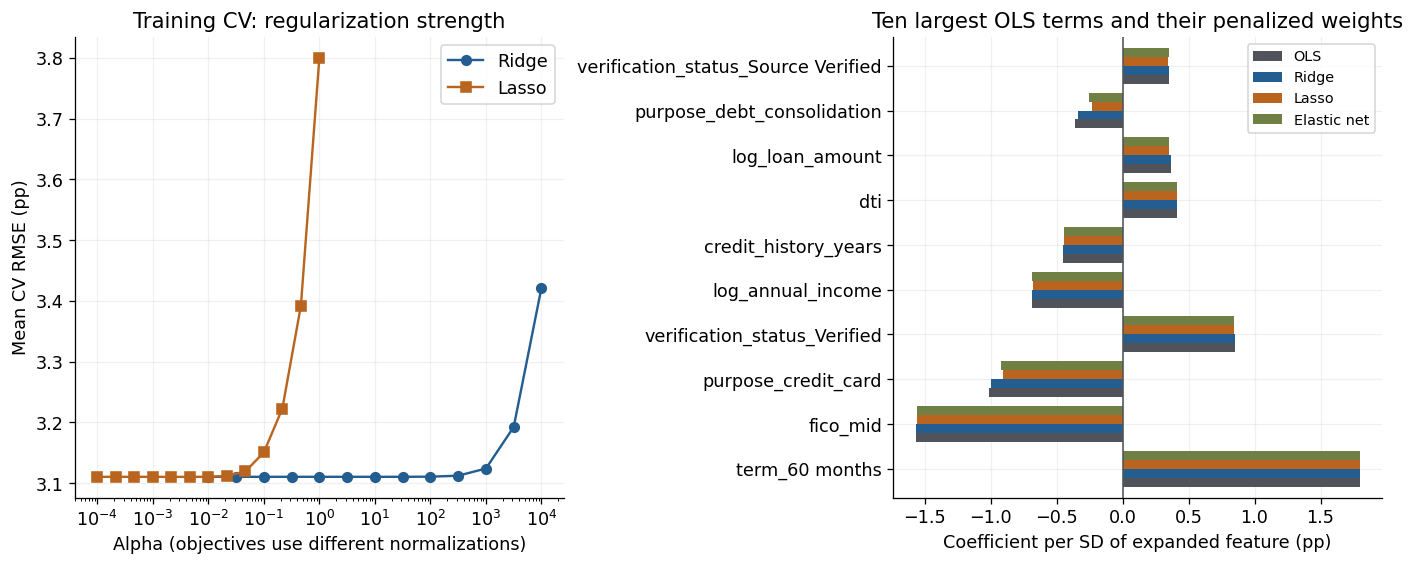

In [6]:
validation_rows = []
coefficient_table = pd.DataFrame(index=fitted['OLS'].named_steps['prepare'].get_feature_names_out())
for name, estimator in fitted.items():
    weights = estimator.named_steps['regress'].coef_
    coefficient_table[name] = weights
    validation_rows.append({'model': name,
        'Train RMSE (pp)': regression_metrics(y_train, estimator.predict(X_train))['RMSE (pp)'],
        **regression_metrics(y_valid, estimator.predict(X_valid)),
        'Nonzero terms': int(np.count_nonzero(np.abs(weights) > 1e-8)),
        'Coefficient L2 norm': np.linalg.norm(weights)})
validation_results = pd.DataFrame(validation_rows).set_index('model')
display(validation_results.sort_values('RMSE (pp)'))
chosen_name = validation_results['RMSE (pp)'].idxmin()
leading_terms = coefficient_table['OLS'].abs().nlargest(10).index
display(coefficient_table.loc[leading_terms])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout='constrained')
for name, color, marker in [('Ridge', BLUE, 'o'), ('Lasso', ORANGE, 's')]:
    cv_results = pd.DataFrame(searches[name].cv_results_)
    axes[0].semilogx(cv_results['param_regress__alpha'].astype(float),
                     -cv_results['mean_test_score'], marker=marker,
                     label=name, color=color)
axes[0].set(title='Training CV: regularization strength',
            xlabel='Alpha (objectives use different normalizations)', ylabel='Mean CV RMSE (pp)')
axes[0].legend()
coefficient_table.loc[leading_terms].plot.barh(ax=axes[1],
    color=[GRAY, BLUE, ORANGE, '#708044'], width=0.8)
axes[1].axvline(0, color=GRAY, linewidth=1)
axes[1].set(title='Ten largest OLS terms and their penalized weights',
            xlabel='Coefficient per SD of expanded feature (pp)', ylabel='')
axes[1].legend(fontsize=9)
plt.show()

Validation selected **Lasso**. Lasso retained **26 of 27** expanded terms. Penalization can stabilize correlated terms, but it is not guaranteed to improve a well-supported OLS fit. Fold-to-fold variation in CV is descriptive and is not a confidence interval for an independent experiment.

### 7. Trace the lasso shrinkage path

This training-only diagnostic shows how increasing alpha shrinks or removes selected coefficients. It does not use the validation or test responses.

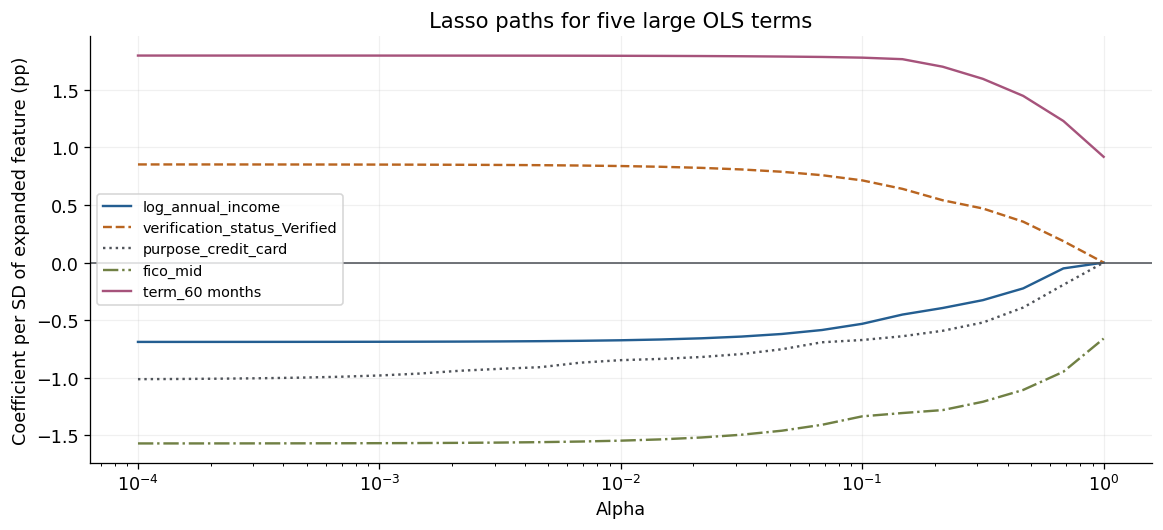

In [7]:
path_prepare = Pipeline([('prepare', make_preprocessor('interaction')),
                         ('scale_expanded', StandardScaler())])
train_matrix = path_prepare.fit_transform(X_train)
feature_names = path_prepare.named_steps['prepare'].get_feature_names_out()
path_alphas = np.logspace(-4, 0, 25)
path_weights = np.array([Lasso(alpha=alpha, max_iter=30_000, tol=1e-6)
                         .fit(train_matrix, y_train).coef_ for alpha in path_alphas])
top_indices = np.argsort(np.abs(fitted['OLS'].named_steps['regress'].coef_))[-5:]
fig, ax = plt.subplots(figsize=(10, 4.5), layout='constrained')
for j, color, style in zip(top_indices, [BLUE, ORANGE, GRAY, '#708044', '#A6537B'],
                          ['-', '--', ':', '-.', '-']):
    ax.semilogx(path_alphas, path_weights[:, j], label=feature_names[j], color=color, linestyle=style)
ax.axhline(0, color=GRAY, linewidth=1)
ax.set(title='Lasso paths for five large OLS terms', xlabel='Alpha',
       ylabel='Coefficient per SD of expanded feature (pp)')
ax.legend(loc='best', fontsize=9)
plt.show()

### 8. Evaluate the chosen family on untouched test loans

Refit the selected configuration on training plus validation data. The final comparison includes prespecified OLS and mean baselines, without reselecting the winner based on test performance.

In [8]:
final_names = list(dict.fromkeys([chosen_name, 'OLS']))
final_models = {name: clone(fitted[name]).fit(X_dev, y_dev) for name in final_names}
final_predictions = {name: model.predict(X_test) for name, model in final_models.items()}
final_predictions['Mean baseline'] = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
test_results = pd.DataFrame({name: regression_metrics(y_test, pred)
                             for name, pred in final_predictions.items()}).T
display(test_results.rename_axis('Final test model'))
# A paired bootstrap measures uncertainty in the fixed models' MAE difference.
# It resamples test loans, not training fits, and assumes independent loans.
chosen_errors = np.abs(y_test.to_numpy() - final_predictions[chosen_name])
ols_errors = np.abs(y_test.to_numpy() - final_predictions['OLS'])
rng = np.random.default_rng(SEED)
differences = np.array([(chosen_errors[index] - ols_errors[index]).mean()
    for index in (rng.integers(0, len(y_test), len(y_test)) for _ in range(500))])
mae_interval = np.quantile(differences, [0.025, 0.975])
display(pd.Series({'Selected minus OLS MAE (pp)': (chosen_errors - ols_errors).mean(),
                   'Paired bootstrap lower 95% (pp)': mae_interval[0],
                   'Paired bootstrap upper 95% (pp)': mae_interval[1]},
                  name='Fixed-model test uncertainty'))

,RMSE (pp),MAE (pp),R²
Final test model,,,
Lasso,3.0636,2.4145,0.4919
OLS,3.0642,2.4146,0.4917
Mean baseline,4.2988,3.4020,-0.0004


Selected minus OLS MAE (pp)       -0.0001
Paired bootstrap lower 95% (pp)   -0.0011
Paired bootstrap upper 95% (pp)    0.0007
Name: Fixed-model test uncertainty, dtype: float64

### Dataset conclusions — accepted_2007_to_2018Q4.csv

1. Validation selected **Lasso**. Its test RMSE was **3.064 pp**, MAE **2.414 pp**, and R² **0.492**. The OLS test RMSE was **3.064 pp**.
2. Lasso retained **26/27** expanded terms; ridge shrinks weights without an explicit sparse-selection objective. Elastic net balances these behaviors through its tuned L1 ratio.
3. The selected-minus-OLS test MAE difference has a paired-bootstrap 95% interval of **[-0.0011, 0.0007] pp**. Negative values favor the selected model. This interval is conditional on the fitted models and excludes retraining/model-selection uncertainty. A tiny difference should not be sold as a large practical gain.
4. All penalties were tuned with fold-specific imputation, encoding, and scaling. The fitted coefficients describe association with issued rates, not causal borrower effects. Selection can be unstable among correlated predictors.

**Capstone implication:** prefer the validated accuracy/interpretability tradeoff over a blanket assumption that regularization must outperform OLS. Next check feature-subset and latent-component approaches, then a later-year holdout.

### Shared tools for the additional independent analyses

Reuse transparent pipeline-building code, not fitted objects or results. Dataset B and Dataset C each reload their own file, redefine the response, reserve their own evaluation data, and fit every method afresh.

In [9]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
    brier_score_loss, accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

class ExtraTerms(TransformerMixin, BaseEstimator):
    """Retain parents; append numeric squares and prespecified interactions."""
    def __init__(self, numeric_count=1, mode='linear'):
        self.numeric_count = numeric_count
        self.mode = mode

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        values = np.asarray(X)
        pieces = [values]
        if self.mode in ('quadratic', 'interaction'):
            pieces.append(values[:, :self.numeric_count] ** 2)
        if self.mode == 'interaction':
            # Interact the first continuous feature with each remaining numeric
            # predictor and category indicator. Do not square 0/1 indicators.
            pieces.append(values[:, [0]] * values[:, 1:])
        return np.column_stack(pieces)

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        result = names.copy()
        if self.mode in ('quadratic', 'interaction'):
            result += [f'{name} squared' for name in names[:self.numeric_count]]
        if self.mode == 'interaction':
            result += [f'{names[0]} × {name}' for name in names[1:]]
        return np.asarray(result, dtype=object)

def extra_preprocessor(numeric, categorical, scaler='standard'):
    """No preparation is learned from validation/test rows."""
    scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(),
               'robust': RobustScaler(), 'none': None}
    transformers = []
    if numeric:
        steps = [('impute', SimpleImputer(strategy='median'))]
        if scalers[scaler] is not None:
            steps.append(('scale', scalers[scaler]))
        transformers.append(('num', Pipeline(steps), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def extra_regressor(numeric, categorical, mode='linear', estimator=None, scale_all=False):
    steps = [('prepare', extra_preprocessor(numeric, categorical)),
             ('terms', ExtraTerms(len(numeric), mode))]
    if scale_all:
        steps.append(('scale_all', StandardScaler()))
    steps.append(('model', LinearRegression() if estimator is None else estimator))
    return Pipeline(steps)

def extra_split(X, y, groups=None, classification=False):
    """Use a row split for loans and account-group separation for bank records."""
    if groups is None:
        development, test = train_test_split(np.arange(len(X)), test_size=0.20,
            random_state=SEED, stratify=y if classification else None)
        train, valid = train_test_split(development, test_size=0.25, random_state=SEED,
            stratify=y.iloc[development] if classification else None)
        cv = (StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
              if classification else KFold(n_splits=3, shuffle=True, random_state=SEED))
        folds = list(cv.split(X.iloc[train], y.iloc[train]))
    else:
        development, test = next(GroupShuffleSplit(n_splits=1, test_size=0.20,
            random_state=SEED).split(X, y, groups))
        train_local, valid_local = next(GroupShuffleSplit(n_splits=1, test_size=0.25,
            random_state=SEED).split(X.iloc[development], y.iloc[development], groups.iloc[development]))
        train, valid = development[train_local], development[valid_local]
        # Do not split records from the same account across CV folds either.
        folds = list(GroupKFold(n_splits=3).split(X.iloc[train], y.iloc[train], groups.iloc[train]))
        sets = [set(groups.iloc[index]) for index in [train, valid, test]]
        assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
    assert len(set(train) | set(valid) | set(test)) == len(X)
    if classification:
        for index in [train, valid, test]:
            assert y.iloc[index].nunique() == 2, 'Both classes are required in every evaluation split.'
        for fit, holdout in folds:
            assert y.iloc[train].iloc[fit].nunique() == 2
            assert y.iloc[train].iloc[holdout].nunique() == 2
    return train, valid, test, development, folds

def extra_metrics(actual, prediction):
    prediction = np.asarray(prediction).ravel()
    return {'RMSE': np.sqrt(mean_squared_error(actual, prediction)),
            'MAE': mean_absolute_error(actual, prediction), 'R²': r2_score(actual, prediction)}

def extra_vif(frame):
    values = StandardScaler().fit_transform(frame)
    rows = []
    for j, name in enumerate(frame.columns):
        if np.std(values[:, j]) < 1e-12:
            value = np.inf
        elif len(frame.columns) == 1:
            value = 1.0
        else:
            r_squared = LinearRegression().fit(np.delete(values, j, axis=1), values[:, j]).score(
                np.delete(values, j, axis=1), values[:, j])
            value = np.inf if 1 - r_squared < 1e-10 else 1 / (1 - r_squared)
        rows.append({'feature': name, 'VIF': value})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

# Store results separately so later sections cannot overwrite another dataset's evidence.
dataset_results = []

### Preserve Dataset A’s verified results

Keep a separate named result record before beginning another dataset.

In [10]:
primary_scores = test_results.loc[chosen_name]
dataset_results.append({'dataset':'accepted_2007_to_2018Q4.csv','outcome':'issued interest rate',
    'unit':'percentage points','training n':len(y_train),'test n':len(y_test),'model':chosen_name,
    'RMSE':primary_scores['RMSE (pp)'],'MAE':primary_scores['MAE (pp)'],'R²':primary_scores['R²'],
    'baseline RMSE':test_results.loc['Mean baseline','RMSE (pp)']})

## B. Loan_Default.csv — independent analysis

**Response:** observed positive `rate_of_interest`; errors are in percentage points.
Use a reproducible random sample of up to 24,000 eligible records. Predictors include
logged loan amount/income, credit score, term, LTV, DTI, loan type, loan purpose, and
occupancy. Status, rate spread, upfront charges, IDs, and duplicated encodings are excluded.

**Selection limitation:** pricing is missing for nearly every Status 1 record.
Restricting to observed rates therefore changes the population substantially; it cannot
describe pricing for excluded records or predict default. The original status labels
and feature timing are not documented. LTV extremes are retained and their potential
influence is diagnosed rather than silently winsorized using evaluation data.

The same eligible sample, predictors, and partitions are reused across Weeks 1–3.
Each new section fits its own preprocessing, models, and evaluation from this CSV.

### B1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [11]:
dataset_name = 'Loan_Default.csv'
outcome_label, outcome_unit = 'observed interest rate', 'percentage points'
response_axis = 'Interest rate (%)'
source_frame = pd.read_csv(DATA_DIR / dataset_name)
assert source_frame['ID'].is_unique and source_frame['ID'].notna().all()
rates = pd.to_numeric(source_frame['rate_of_interest'], errors='coerce')
eligible = rates.gt(0) & rates.le(100)
loan_missingness = pd.crosstab(source_frame['Status'], rates.isna()).rename(
    columns={False: 'Rate observed', True: 'Rate missing'})
display(loan_missingness)
frame = source_frame.loc[eligible].sample(n=min(24_000, int(eligible.sum())), random_state=SEED).copy()
frame = frame.reset_index(drop=True)
display(pd.Series({'CSV records': len(source_frame), 'valid positive-rate records': eligible.sum(),
    'excluded records': (~eligible).sum(), 'sampled records': len(frame),
    'Status 1 share in eligible population': source_frame.loc[eligible, 'Status'].mean()}, name='Rate cohort'))
X = pd.DataFrame({
    'log_loan_amount': np.log1p(frame['loan_amount'].where(frame['loan_amount'] > 0)),
    'log_income': np.log1p(frame['income'].where(frame['income'] >= 0)),
    'Credit_Score': frame['Credit_Score'], 'term': frame['term'],
    'LTV': frame['LTV'].where(frame['LTV'] >= 0), 'dtir1': frame['dtir1']})
numeric = list(X.columns)
categorical = ['loan_type', 'loan_purpose', 'occupancy_type']
for name in categorical:
    X[name] = frame[name].astype(object).where(frame[name].notna(), np.nan)
y = frame['rate_of_interest'].astype(float)
groups = None

rate_of_interest,Rate observed,Rate missing
Status,,
0,112031,0
1,200,36439


CSV records                             148,670.0000
valid positive-rate records             112,230.0000
excluded records                         36,440.0000
sampled records                          24,000.0000
Status 1 share in eligible population         0.0018
Name: Rate cohort, dtype: float64

### B2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [12]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=False)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean
training,14400,4.0353
validation,4800,4.0478
test,4800,4.0569


,Training missing (%)
log_loan_amount,0.0000
log_income,7.4028
Credit_Score,0.0000
term,0.0000
LTV,0.0069
dtir1,7.2917
loan_type,0.0000
loan_purpose,0.1111
occupancy_type,0.0000


### B3. Explore this dataset’s training response

Show the response distribution and its relationship with the first continuous predictor. Large-loan samples use translucent points; the bank plot displays every training record. These associations do not establish causation.

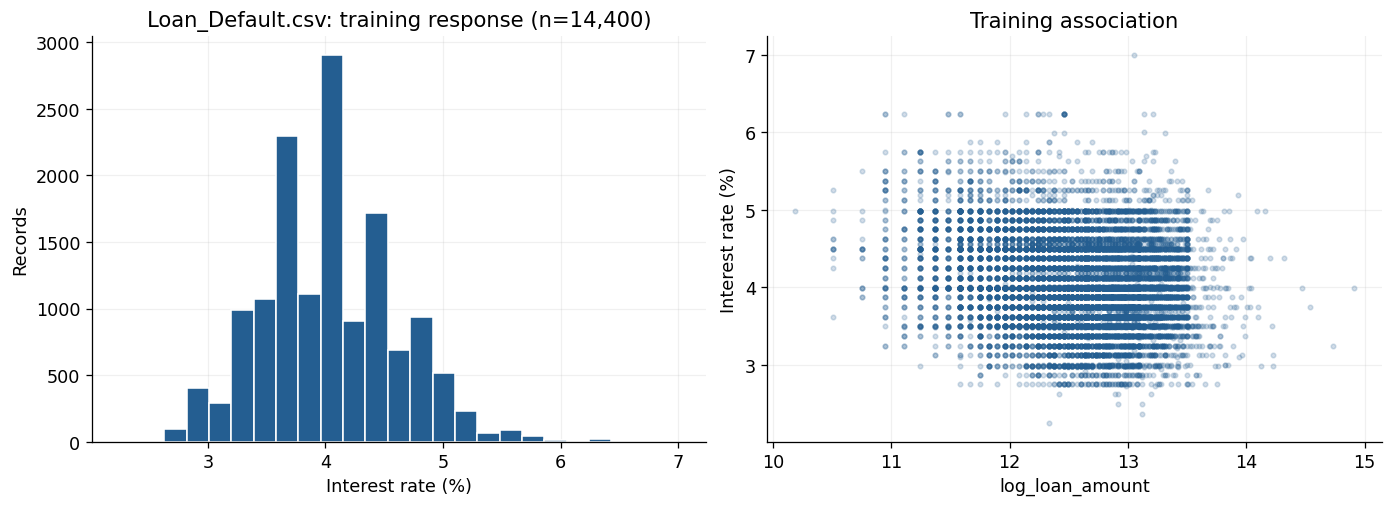

,Training response
count,"14,400.0000"
mean,4.0353
std,0.5600
min,2.2500
25%,3.6250
50%,3.9900
75%,4.3750
max,7.0000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
axes[0].hist(y_train, bins=min(25, max(5, len(y_train)//3)), color=BLUE, edgecolor='white')
axes[0].set(title=f'{dataset_name}: training response (n={len(y_train):,})',
            xlabel=response_axis, ylabel='Records')
axes[1].scatter(X_train[numeric[0]], y_train, s=20 if len(y_train)<100 else 8,
                alpha=0.8 if len(y_train)<100 else 0.2, color=BLUE)
axes[1].set(title='Training association', xlabel=numeric[0],
            ylabel=response_axis)
plt.show()
display(y_train.describe().rename('Training response').to_frame())

### B4. Fit OLS, ridge, lasso, and elastic net to this dataset

Repeat all four families on this dataset’s own quadratic/interaction design. Standardize expanded numeric and dummy columns before penalization. CV selects alpha and the elastic-net L1 ratio; validation selects the family. The same alpha need not have the same meaning across penalties or response units.

In [14]:
specifications = {
    'Ridge': (Ridge(), {'model__alpha': np.logspace(-2, 5, 10)}),
    'Lasso': (Lasso(max_iter=100_000, tol=1e-5), {'model__alpha': np.logspace(-4, 2, 10)}),
    'Elastic net': (ElasticNet(max_iter=100_000, tol=1e-5),
        {'model__alpha': np.logspace(-4, 2, 8), 'model__l1_ratio': [0.1, 0.5, 0.9]})}
fitted = {'OLS': extra_regressor(numeric, categorical, 'interaction', scale_all=True).fit(X_train,y_train)}
searches = {}
tuning = []
for name, (estimator, grid) in specifications.items():
    search = GridSearchCV(extra_regressor(numeric, categorical, 'interaction', estimator, True),
        grid, cv=folds, scoring='neg_root_mean_squared_error', n_jobs=1, error_score='raise')
    search.fit(X_train, y_train)
    searches[name], fitted[name] = search, search.best_estimator_
    tuning.append({'model': name, 'alpha': search.best_params_['model__alpha'],
        'L1 ratio': search.best_params_.get('model__l1_ratio', np.nan), 'CV RMSE': -search.best_score_})
display(pd.DataFrame(tuning).set_index('model'))

,alpha,L1 ratio,CV RMSE
model,,,
Ridge,77.4264,NaN,0.4434
Lasso,0.0005,NaN,0.4434
Elastic net,0.0052,0.1000,0.4434


### B5. Compare error, shrinkage, and selected terms

The coefficient table and nonzero count are calculated independently for this dataset. Lasso zeros are model choices, not evidence of no real association. The two panels show validation error and coefficient shrinkage.

,RMSE,MAE,R²,nonzero terms,coefficient L2 norm
model,,,,,
OLS,0.4401,0.3424,0.3932,31,0.4233
Ridge,0.4402,0.3425,0.3932,31,0.4155
Lasso,0.4402,0.3426,0.3931,31,0.4161
Elastic net,0.4402,0.3427,0.3930,31,0.4089


,OLS,Ridge,Lasso,Elastic net
loan_type_type3,-0.1993,-0.1971,-0.1983,-0.1962
LTV,0.1428,0.1395,0.1408,0.1376
occupancy_type_pr,-0.1286,-0.1275,-0.1275,-0.1265
log_loan_amount,-0.1235,-0.1152,-0.1172,-0.1098
loan_type_type2,-0.1227,-0.1206,-0.1215,-0.1195
log_income,0.1090,0.1054,0.1049,0.1016
loan_purpose_p3,0.1069,0.1042,0.1051,0.1026


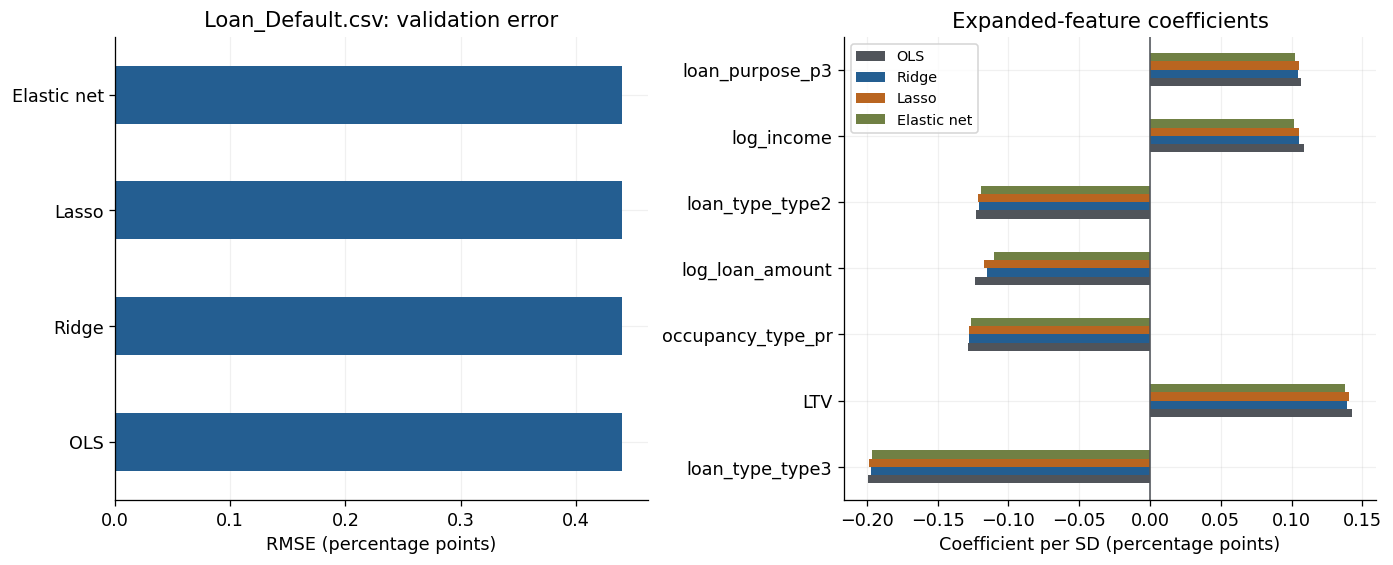

In [15]:
weights = pd.DataFrame(index=fitted['OLS'][:-1].get_feature_names_out())
rows = []
for name, estimator in fitted.items():
    weights[name] = estimator.named_steps['model'].coef_
    rows.append({'model': name, **extra_metrics(y_valid, estimator.predict(X_valid)),
        'nonzero terms': int(np.count_nonzero(np.abs(weights[name]) > 1e-8)),
        'coefficient L2 norm': np.linalg.norm(weights[name])})
validation = pd.DataFrame(rows).set_index('model')
display(validation.sort_values('RMSE'))
chosen_name = validation['RMSE'].idxmin()
top = weights['OLS'].abs().nlargest(min(7,len(weights))).index
display(weights.loc[top])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout='constrained')
validation['RMSE'].plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title=f'{dataset_name}: validation error', xlabel=f'RMSE ({outcome_unit})', ylabel='')
weights.loc[top].plot.barh(ax=axes[1], color=[GRAY, BLUE, ORANGE, '#708044'])
axes[1].axvline(0, color=GRAY, linewidth=1)
axes[1].set(title='Expanded-feature coefficients', xlabel=f'Coefficient per SD ({outcome_unit})', ylabel='')
axes[1].legend(fontsize=9)
plt.show()

### B6. Inspect penalty strength and the lasso path

Use training data only for these diagnostics. The lasso path shows the largest OLS terms across alpha; CV curves show where excess shrinkage hurts prediction.

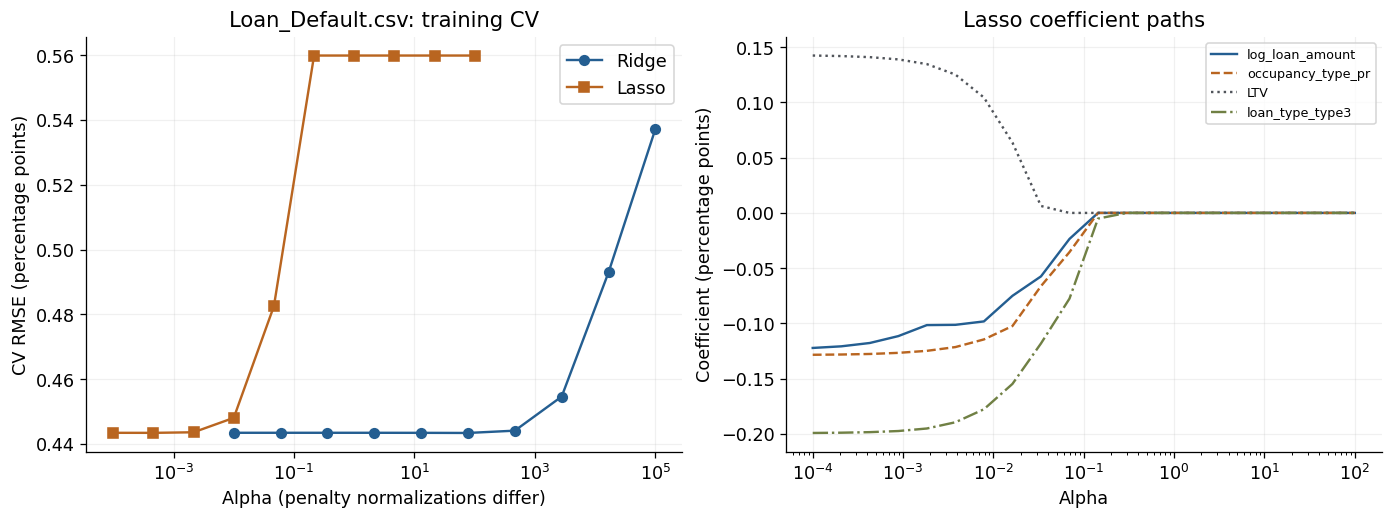

In [16]:
train_matrix = fitted['OLS'][:-1].transform(X_train)
alphas = np.logspace(-4, 2, 20)
path = np.array([Lasso(alpha=alpha,max_iter=100_000,tol=1e-5).fit(train_matrix,y_train).coef_ for alpha in alphas])
leading = np.argsort(np.abs(weights['OLS'].to_numpy()))[-min(4,len(weights)):]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
for name,color,marker in [('Ridge',BLUE,'o'),('Lasso',ORANGE,'s')]:
    result = pd.DataFrame(searches[name].cv_results_)
    axes[0].semilogx(result['param_model__alpha'].astype(float),-result['mean_test_score'],
                     marker=marker,color=color,label=name)
axes[0].set(title=f'{dataset_name}: training CV',xlabel='Alpha (penalty normalizations differ)',
            ylabel=f'CV RMSE ({outcome_unit})')
axes[0].legend()
for j,color,style in zip(leading,[BLUE,ORANGE,GRAY,'#708044'],['-','--',':','-.']):
    axes[1].semilogx(alphas,path[:,j],color=color,linestyle=style,label=weights.index[j])
axes[1].set(title='Lasso coefficient paths',xlabel='Alpha',ylabel=f'Coefficient ({outcome_unit})')
axes[1].legend(fontsize=8)
plt.show()
method_finding = (f"Lasso retained **{int(validation.loc['Lasso','nonzero terms'])}/{len(weights)}** "
    f"expanded terms. OLS validation RMSE was **{validation.loc['OLS','RMSE']:.3f} {outcome_unit}**, "
    f"compared with **{validation.loc[chosen_name,'RMSE']:.3f} {outcome_unit}** for the selected family. "
    "Scaling and penalization were fitted within this dataset's CV folds; selection is not a significance test.")

### B7. Evaluate and diagnose this dataset’s final model

Freeze the validation-selected family/configuration, refit on development rows, and evaluate on the test partition. Report the mean-only baseline, residuals, and the test sample size. Negative R² is retained when the model underperforms.

,RMSE,MAE,R²
OLS,0.4424,0.3488,0.3547
Development-mean baseline,0.5510,0.4368,-0.0011


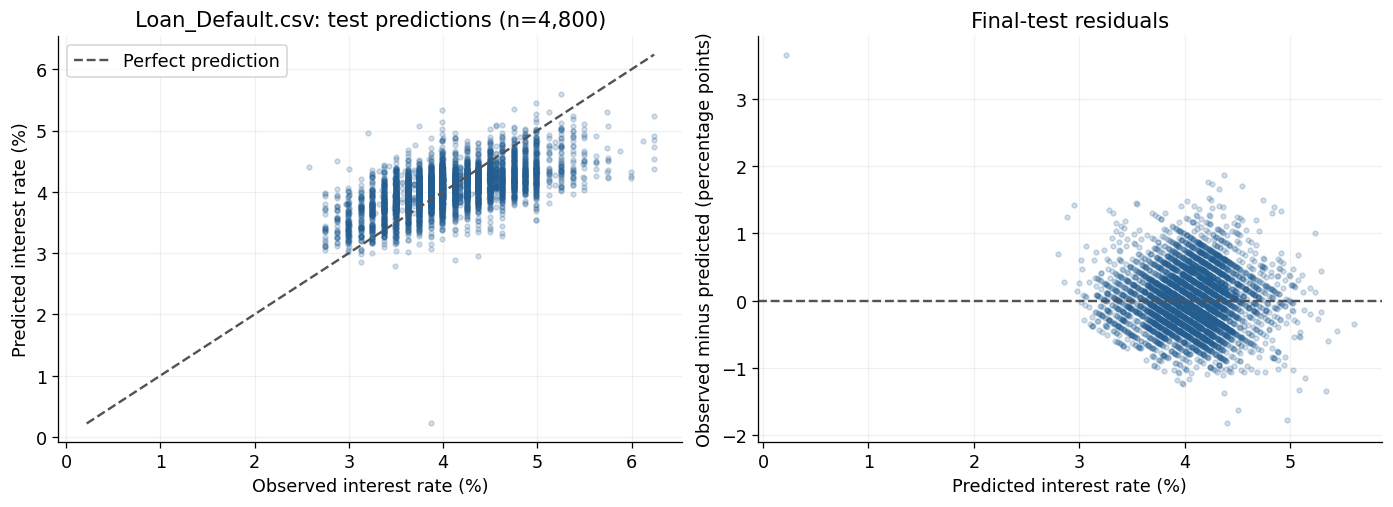

In [17]:
final_model = clone(fitted[chosen_name]).fit(X_dev, y_dev)
prediction = np.asarray(final_model.predict(X_test)).ravel()
baseline = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
final_scores = extra_metrics(y_test, prediction)
baseline_scores = extra_metrics(y_test, baseline)
display(pd.DataFrame([final_scores, baseline_scores], index=[chosen_name, 'Development-mean baseline']))
residuals = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
alpha = 0.8 if len(y_test) < 100 else 0.20
axes[0].scatter(y_test, prediction, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, '--', color=GRAY, label='Perfect prediction')
axes[0].set(title=f'{dataset_name}: test predictions (n={len(y_test):,})',
            xlabel=f'Observed {response_axis.lower()}',
            ylabel=f'Predicted {response_axis.lower()}')
axes[0].legend()
axes[1].scatter(prediction, residuals, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
axes[1].axhline(0, linestyle='--', color=GRAY)
axes[1].set(title='Final-test residuals', xlabel=f'Predicted {response_axis.lower()}',
            ylabel=f'Observed minus predicted ({outcome_unit})')
plt.show()
assert np.isfinite(prediction).all()
if dataset_name == 'bank_customers.csv':
    print(f'Negative predicted tenure values: {int((prediction < 0).sum())}/{len(prediction)}; values are not clipped.')
dataset_results.append({'dataset': dataset_name, 'outcome': outcome_label, 'unit': outcome_unit,
    'training n': len(y_train), 'test n': len(y_test), 'model': chosen_name,
    **final_scores, 'baseline RMSE': baseline_scores['RMSE']})

### Dataset conclusions — Loan_Default.csv

Validation selected **OLS**. Test RMSE was **0.442 percentage points**, MAE **0.349 percentage points**, and R² **0.355** on **4,800** records. RMSE was **lower** than the development-mean baseline (**0.551 percentage points**).

Lasso retained **31/31** expanded terms. OLS validation RMSE was **0.440 percentage points**, compared with **0.440 percentage points** for the selected family. Scaling and penalization were fitted within this dataset's CV folds; selection is not a significance test.

The outcome is observed pricing in an eligible subset that excludes nearly all Status 1 records. It does not generalize to missing-rate loans or establish default risk.

## C. bank_customers.csv — independent analysis

The continuous response is **account tenure in years as of September 26, 2026**. Predictors are age at that same date and account type. This is a retrospective account-profile association, not a loan/default model or a causal forecast. Opening date is used only to calculate the response and is excluded from predictors.

**Date and grain decisions.** Exclude future opening dates, missing/unparseable/partial
birth dates, dates after the reference date, opening before birth, and unrecognized account
types. Year-only birth dates are not converted into invented full dates. Eligibility flags
can overlap. Account openings during childhood are retained because custodial accounts are
possible; product eligibility is not documented. Repeated account IDs stay together in
train/validation/test and CV. IDs are group keys, not numeric predictors.

**Interpretation limit.** The original file has only 100 rows and many invalid dates.
The valid subset is very small and not representative of all records. Exact predictive
scores will be unstable; these models demonstrate the weekly methods on genuine observed
account fields. Derived age and tenure share a reference date; their association can
partly reflect the arithmetic constraint that an account cannot predate birth.
SSNs are excluded at read time and identifiers are never displayed.

### C1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [18]:
dataset_name = 'bank_customers.csv'
source_frame = pd.read_csv(DATA_DIR / dataset_name, usecols=lambda name: name != 'SSN')
AS_OF = pd.Timestamp('2026-09-26')
birth_text = source_frame['BirthDate'].astype('string').str.strip()
partial_birth = birth_text.str.fullmatch(r'\d{4}', na=False)
birth = pd.to_datetime(birth_text.mask(partial_birth), format='mixed', errors='coerce')
opened = pd.to_datetime(source_frame['AccountOpened'], format='mixed', errors='coerce')
valid_type = source_frame['AccountType'].isin(['checking', 'savings', 'cd'])
eligible = (birth.notna() & opened.notna() & birth.le(AS_OF) & opened.le(AS_OF)
            & opened.ge(birth) & valid_type)
# Reason flags overlap; the union, not their sum, determines exclusions.
display(pd.Series({'source records': len(source_frame),
    'missing/invalid/partial birth date': birth.isna().sum(),
    'missing/invalid opening date': opened.isna().sum(),
    'future opening date': opened.gt(AS_OF).sum(),
    'opening before exact birth date': opened.lt(birth).sum(),
    'missing/unrecognized account type': (~valid_type).sum(),
    'eligible records': eligible.sum(), 'excluded union': (~eligible).sum()}, name='Bank eligibility audit'))
frame = source_frame.loc[eligible].copy()
frame['age_years'] = (AS_OF - birth.loc[eligible]).dt.days / 365.25
frame['tenure_years'] = (AS_OF - opened.loc[eligible]).dt.days / 365.25
# Repeated AccountID values are conservatively grouped, even though this file
# does not document whether they represent shared accounts or data-quality issues.
frame['_group'] = frame['AccountID'].astype('string')
frame['_group'] = frame['_group'].fillna(pd.Series(
    ['missing_account_' + str(i) for i in frame.index], index=frame.index))
frame = frame.reset_index(drop=True)
groups = frame['_group']
assert len(frame) >= 20
display(frame['AccountType'].value_counts().rename('eligible records').to_frame())
# BirthDate, CustomerID, AccountID, and SSN are never displayed or used as model features.

outcome_label, outcome_unit = 'account tenure', 'years'
response_axis = 'Account tenure (years)'
X = frame[['age_years', 'AccountType']].copy()
y = frame['tenure_years']
numeric, categorical = ['age_years'], ['AccountType']

source records                        100
missing/invalid/partial birth date      3
missing/invalid opening date            1
future opening date                    59
opening before exact birth date         0
missing/unrecognized account type       1
eligible records                       39
excluded union                         61
Name: Bank eligibility audit, dtype: int64

,eligible records
AccountType,
checking,16
savings,15
cd,8


### C2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [19]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=False)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean,account groups
training,24,26.3941,21
validation,7,20.7228,7
test,8,18.8433,8


,Training missing (%)
age_years,0.0000
AccountType,0.0000


### C3. Explore this dataset’s training response

Show the response distribution and its relationship with the first continuous predictor. Large-loan samples use translucent points; the bank plot displays every training record. These associations do not establish causation.

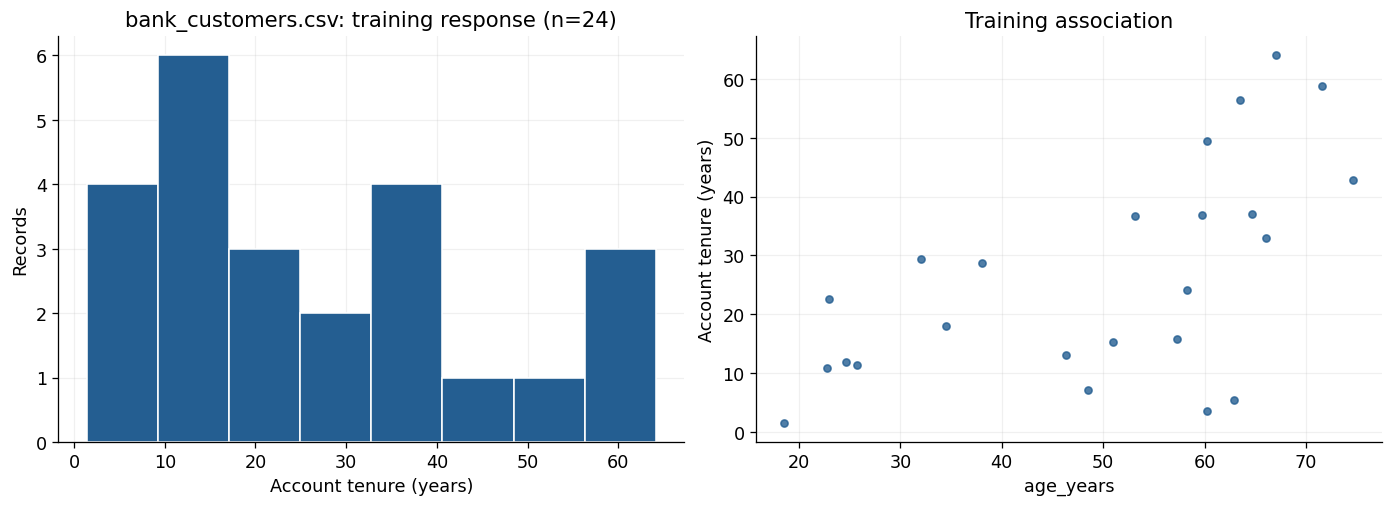

,Training response
count,24.0000
mean,26.3941
std,18.3239
min,1.3990
25%,11.6797
50%,23.3566
75%,36.9103
max,64.1396


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
axes[0].hist(y_train, bins=min(25, max(5, len(y_train)//3)), color=BLUE, edgecolor='white')
axes[0].set(title=f'{dataset_name}: training response (n={len(y_train):,})',
            xlabel=response_axis, ylabel='Records')
axes[1].scatter(X_train[numeric[0]], y_train, s=20 if len(y_train)<100 else 8,
                alpha=0.8 if len(y_train)<100 else 0.2, color=BLUE)
axes[1].set(title='Training association', xlabel=numeric[0],
            ylabel=response_axis)
plt.show()
display(y_train.describe().rename('Training response').to_frame())

### C4. Fit OLS, ridge, lasso, and elastic net to this dataset

Repeat all four families on this dataset’s own quadratic/interaction design. Standardize expanded numeric and dummy columns before penalization. CV selects alpha and the elastic-net L1 ratio; validation selects the family. The same alpha need not have the same meaning across penalties or response units.

In [21]:
specifications = {
    'Ridge': (Ridge(), {'model__alpha': np.logspace(-2, 5, 10)}),
    'Lasso': (Lasso(max_iter=100_000, tol=1e-5), {'model__alpha': np.logspace(-4, 2, 10)}),
    'Elastic net': (ElasticNet(max_iter=100_000, tol=1e-5),
        {'model__alpha': np.logspace(-4, 2, 8), 'model__l1_ratio': [0.1, 0.5, 0.9]})}
fitted = {'OLS': extra_regressor(numeric, categorical, 'interaction', scale_all=True).fit(X_train,y_train)}
searches = {}
tuning = []
for name, (estimator, grid) in specifications.items():
    search = GridSearchCV(extra_regressor(numeric, categorical, 'interaction', estimator, True),
        grid, cv=folds, scoring='neg_root_mean_squared_error', n_jobs=1, error_score='raise')
    search.fit(X_train, y_train)
    searches[name], fitted[name] = search, search.best_estimator_
    tuning.append({'model': name, 'alpha': search.best_params_['model__alpha'],
        'L1 ratio': search.best_params_.get('model__l1_ratio', np.nan), 'CV RMSE': -search.best_score_})
display(pd.DataFrame(tuning).set_index('model'))

,alpha,L1 ratio,CV RMSE
model,,,
Ridge,77.4264,NaN,18.2800
Lasso,4.6416,NaN,17.0582
Elastic net,1.9307,0.9000,18.1164


### C5. Compare error, shrinkage, and selected terms

The coefficient table and nonzero count are calculated independently for this dataset. Lasso zeros are model choices, not evidence of no real association. The two panels show validation error and coefficient shrinkage.

,RMSE,MAE,R²,nonzero terms,coefficient L2 norm
model,,,,,
OLS,20.7808,16.9970,0.1427,6,15.0585
Elastic net,21.0772,17.3902,0.1181,4,7.4370
Lasso,21.4853,17.7000,0.0836,1,5.9581
Ridge,22.3535,18.4054,0.0080,6,2.8095


,OLS,Ridge,Lasso,Elastic net
age_years,13.5239,2.2358,5.9581,7.2889
age_years squared,5.6601,0.0133,0.0000,0.3604
AccountType_checking,-2.2012,-0.8113,-0.0000,-1.2745
AccountType_savings,1.7693,-0.1821,0.0000,-0.0000
age_years × AccountType_savings,1.5540,1.1723,0.0000,0.6533
age_years × AccountType_checking,-1.1969,0.9103,0.0000,0.0000


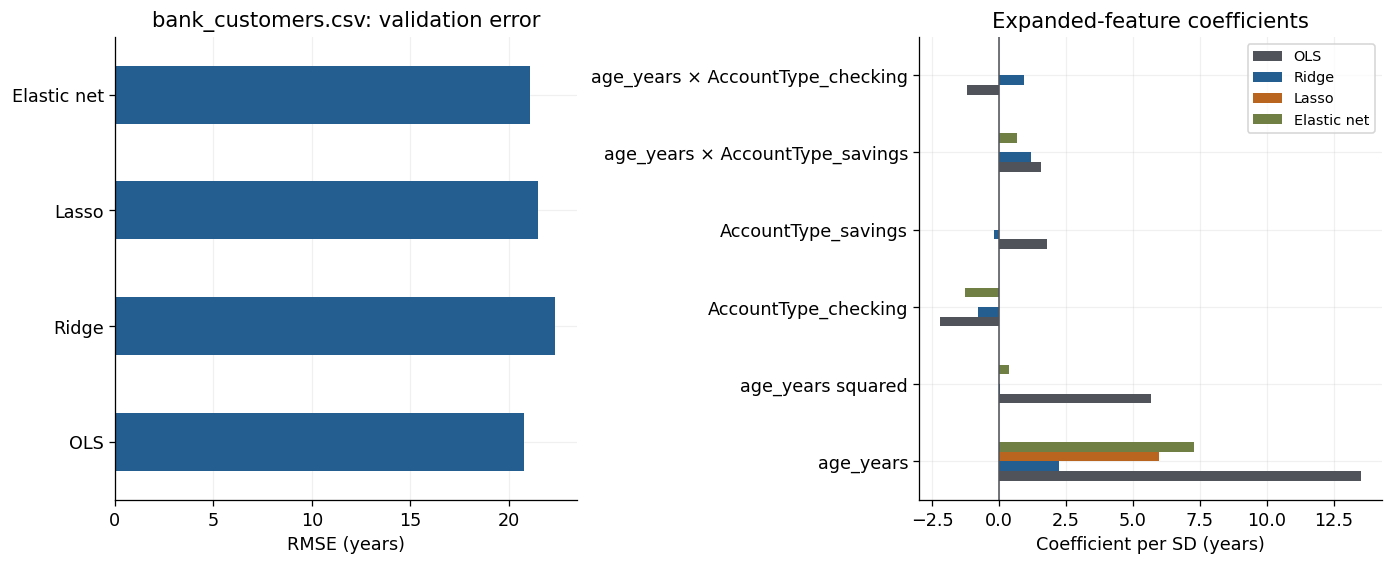

In [22]:
weights = pd.DataFrame(index=fitted['OLS'][:-1].get_feature_names_out())
rows = []
for name, estimator in fitted.items():
    weights[name] = estimator.named_steps['model'].coef_
    rows.append({'model': name, **extra_metrics(y_valid, estimator.predict(X_valid)),
        'nonzero terms': int(np.count_nonzero(np.abs(weights[name]) > 1e-8)),
        'coefficient L2 norm': np.linalg.norm(weights[name])})
validation = pd.DataFrame(rows).set_index('model')
display(validation.sort_values('RMSE'))
chosen_name = validation['RMSE'].idxmin()
top = weights['OLS'].abs().nlargest(min(7,len(weights))).index
display(weights.loc[top])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout='constrained')
validation['RMSE'].plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title=f'{dataset_name}: validation error', xlabel=f'RMSE ({outcome_unit})', ylabel='')
weights.loc[top].plot.barh(ax=axes[1], color=[GRAY, BLUE, ORANGE, '#708044'])
axes[1].axvline(0, color=GRAY, linewidth=1)
axes[1].set(title='Expanded-feature coefficients', xlabel=f'Coefficient per SD ({outcome_unit})', ylabel='')
axes[1].legend(fontsize=9)
plt.show()

### C6. Inspect penalty strength and the lasso path

Use training data only for these diagnostics. The lasso path shows the largest OLS terms across alpha; CV curves show where excess shrinkage hurts prediction.

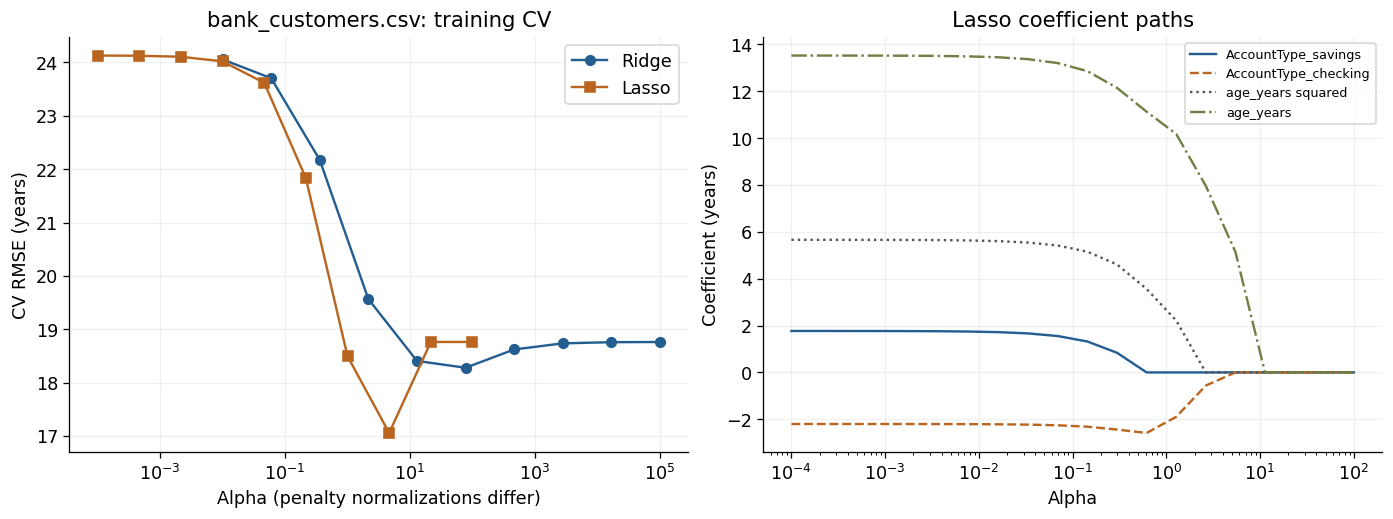

In [23]:
train_matrix = fitted['OLS'][:-1].transform(X_train)
alphas = np.logspace(-4, 2, 20)
path = np.array([Lasso(alpha=alpha,max_iter=100_000,tol=1e-5).fit(train_matrix,y_train).coef_ for alpha in alphas])
leading = np.argsort(np.abs(weights['OLS'].to_numpy()))[-min(4,len(weights)):]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
for name,color,marker in [('Ridge',BLUE,'o'),('Lasso',ORANGE,'s')]:
    result = pd.DataFrame(searches[name].cv_results_)
    axes[0].semilogx(result['param_model__alpha'].astype(float),-result['mean_test_score'],
                     marker=marker,color=color,label=name)
axes[0].set(title=f'{dataset_name}: training CV',xlabel='Alpha (penalty normalizations differ)',
            ylabel=f'CV RMSE ({outcome_unit})')
axes[0].legend()
for j,color,style in zip(leading,[BLUE,ORANGE,GRAY,'#708044'],['-','--',':','-.']):
    axes[1].semilogx(alphas,path[:,j],color=color,linestyle=style,label=weights.index[j])
axes[1].set(title='Lasso coefficient paths',xlabel='Alpha',ylabel=f'Coefficient ({outcome_unit})')
axes[1].legend(fontsize=8)
plt.show()
method_finding = (f"Lasso retained **{int(validation.loc['Lasso','nonzero terms'])}/{len(weights)}** "
    f"expanded terms. OLS validation RMSE was **{validation.loc['OLS','RMSE']:.3f} {outcome_unit}**, "
    f"compared with **{validation.loc[chosen_name,'RMSE']:.3f} {outcome_unit}** for the selected family. "
    "Scaling and penalization were fitted within this dataset's CV folds; selection is not a significance test.")

### C7. Evaluate and diagnose this dataset’s final model

Freeze the validation-selected family/configuration, refit on development rows, and evaluate on the test partition. Report the mean-only baseline, residuals, and the test sample size. Negative R² is retained when the model underperforms.

,RMSE,MAE,R²
OLS,11.1762,9.7218,-0.1556
Development-mean baseline,12.1410,10.3660,-0.3637


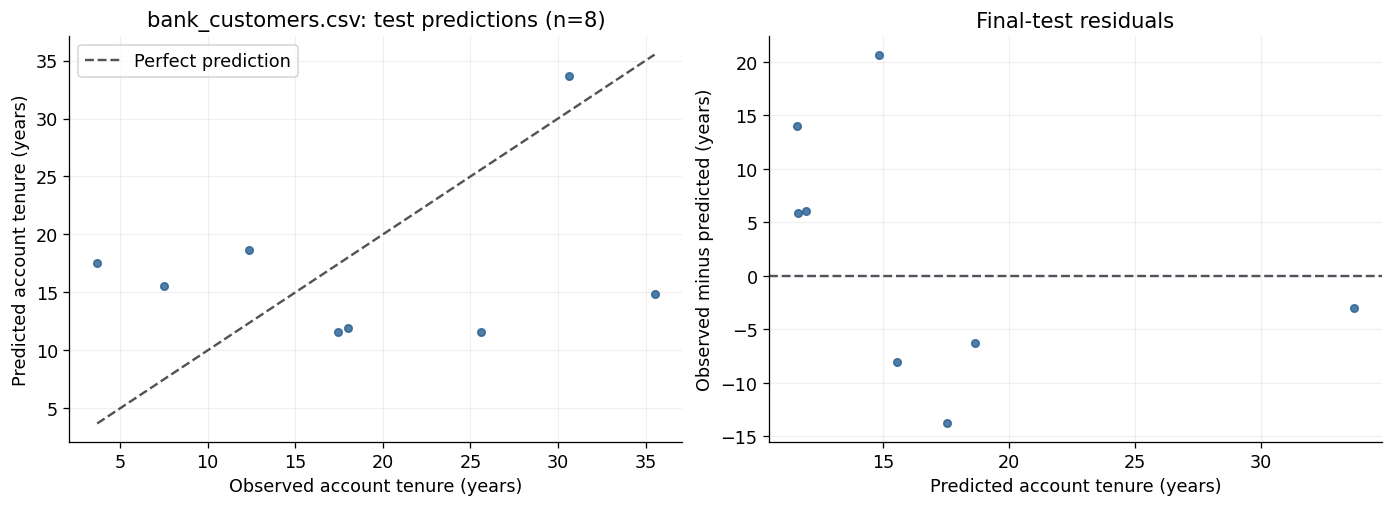

Negative predicted tenure values: 0/8; values are not clipped.


In [24]:
final_model = clone(fitted[chosen_name]).fit(X_dev, y_dev)
prediction = np.asarray(final_model.predict(X_test)).ravel()
baseline = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
final_scores = extra_metrics(y_test, prediction)
baseline_scores = extra_metrics(y_test, baseline)
display(pd.DataFrame([final_scores, baseline_scores], index=[chosen_name, 'Development-mean baseline']))
residuals = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
alpha = 0.8 if len(y_test) < 100 else 0.20
axes[0].scatter(y_test, prediction, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, '--', color=GRAY, label='Perfect prediction')
axes[0].set(title=f'{dataset_name}: test predictions (n={len(y_test):,})',
            xlabel=f'Observed {response_axis.lower()}',
            ylabel=f'Predicted {response_axis.lower()}')
axes[0].legend()
axes[1].scatter(prediction, residuals, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
axes[1].axhline(0, linestyle='--', color=GRAY)
axes[1].set(title='Final-test residuals', xlabel=f'Predicted {response_axis.lower()}',
            ylabel=f'Observed minus predicted ({outcome_unit})')
plt.show()
assert np.isfinite(prediction).all()
if dataset_name == 'bank_customers.csv':
    print(f'Negative predicted tenure values: {int((prediction < 0).sum())}/{len(prediction)}; values are not clipped.')
dataset_results.append({'dataset': dataset_name, 'outcome': outcome_label, 'unit': outcome_unit,
    'training n': len(y_train), 'test n': len(y_test), 'model': chosen_name,
    **final_scores, 'baseline RMSE': baseline_scores['RMSE']})

### Dataset conclusions — bank_customers.csv

Validation selected **OLS**. Test RMSE was **11.176 years**, MAE **9.722 years**, and R² **-0.156** on **8** records. RMSE was **lower** than the development-mean baseline (**12.141 years**).

Lasso retained **1/6** expanded terms. OLS validation RMSE was **20.781 years**, compared with **20.781 years** for the selected family. Scaling and penalization were fitted within this dataset's CV folds; selection is not a significance test.

Only a small historical, date-valid subset is modeled; account-group separation prevents repeat-account leakage but leaves very few validation/test observations. Scores are descriptive demonstrations, not stable estimates of customer behavior.

**Baseline interpretation:** R² compares predictions with the mean of this particular test set. The fitted baseline uses the development-set mean, so a model can beat that feasible baseline while still having negative test R². Unconstrained OLS can also produce negative tenure; the validity count printed above is retained rather than silently clipping predictions.

## Method references

- [scikit-learn: linear models](https://scikit-learn.org/stable/modules/linear_model.html)
- [scikit-learn: preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [scikit-learn: feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)
- [scikit-learn: PCR versus PLS](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Dataset observations in this notebook come from the local CSV files; the links explain methods, not dataset provenance. The original assignment text is preserved above. Its omitted Milestone One rubric/link still needs to be checked before final submission.

### Reconcile coverage across the three datasets

Each row comes from a separately fitted workflow above. Response units and sample sizes are retained to prevent false comparisons between different tasks.

In [25]:
all_dataset_results = pd.DataFrame(dataset_results).set_index('dataset')
assert set(all_dataset_results.index) == {
    'accepted_2007_to_2018Q4.csv','Loan_Default.csv','bank_customers.csv'}
with pd.option_context('display.max_columns',None,'display.max_colwidth',75):
    display(all_dataset_results)

,outcome,unit,training n,test n,model,RMSE,MAE,R²,baseline RMSE
dataset,,,,,,,,,
accepted_2007_to_2018Q4.csv,issued interest rate,percentage points,14400,4800,Lasso,3.0636,2.4145,0.4919,4.2988
Loan_Default.csv,observed interest rate,percentage points,14400,4800,OLS,0.4424,0.3488,0.3547,0.5510
bank_customers.csv,account tenure,years,24,8,OLS,11.1762,9.7218,-0.1556,12.1410


## Overall conclusions

- **accepted_2007_to_2018Q4.csv**: Lasso; test RMSE **3.064 percentage points**, MAE **2.414 percentage points**, R² **0.492**, test n = **4,800**. Development-mean baseline RMSE: **4.299 percentage points**.
- **Loan_Default.csv**: OLS; test RMSE **0.442 percentage points**, MAE **0.349 percentage points**, R² **0.355**, test n = **4,800**. Development-mean baseline RMSE: **0.551 percentage points**.
- **bank_customers.csv**: OLS; test RMSE **11.176 years**, MAE **9.722 years**, R² **-0.156**, test n = **8**. Development-mean baseline RMSE: **12.141 years**.

Each dataset now has its own full application of this week's required methods. LendingClub models issued rates in a 2015 cohort; Loan_Default models observed rates in a heavily selected subset; bank_customers models historical account tenure. Their errors use different populations and, for the bank file, different units. The small bank holdout is a method demonstration, not a reliable performance claim. The dataset-specific conclusions above explain the observed selection, shrinkage, or component tradeoff. No result establishes causality or future-cohort validity.